,classe_meteorito,massa_total_gramas,massa_total_toneladas
227,"Iron, IIIAB",1.388209e+08,138.820889
205,"Iron, IAB-MG",1.080284e+08,108.028420
235,"Iron, IVB",6.051966e+07,60.519660
236,"Iron, ungrouped",4.770401e+07,47.704012
217,"Iron, IIAB",3.775776e+07,37.757756
213,"Iron, IAB-ung",3.155623e+07,31.556228
233,"Iron, IVA",3.105755e+07,31.057547
230,"Iron, IIIE",2.906560e+07,29.065602
183,H5,1.546156e+07,15.461560
332,L6,1.200823e+07,12.008228


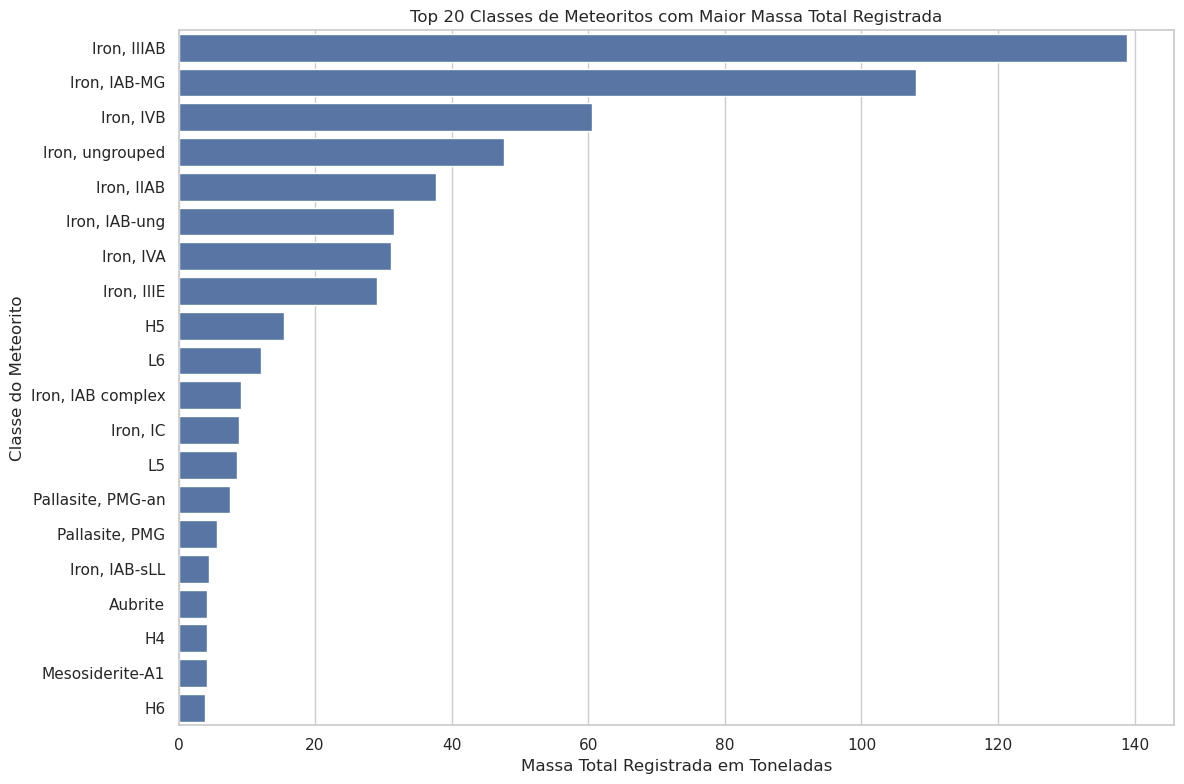

In [1]:
# Importa biblioteca principal para análise de dados
import pandas as pd

# Importa bibliotecas para criação de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Importa biblioteca para exibir tabelas no Jupyter
from IPython.display import display

# Importa bibliotecas para limpar nomes das colunas
import re
import unicodedata

# Define o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# Faz o Pandas mostrar todas as colunas
pd.set_option("display.max_columns", None)

# Faz o Pandas mostrar até 100 linhas
pd.set_option("display.max_rows", 100)

# Link direto do dataset da NASA
url = "https://data.nasa.gov/docs/legacy/meteorite_landings/Meteorite_Landings.csv"

# Lê o dataset direto do link
df = pd.read_csv(url)

# Função para padronizar os nomes das colunas
def limpar_nome_coluna(nome):
    # Converte o nome da coluna para texto
    nome = str(nome)

    # Remove acentos, caso existam
    nome = unicodedata.normalize("NFKD", nome)
    nome = nome.encode("ascii", "ignore").decode("utf-8")

    # Converte para letras minúsculas
    nome = nome.lower()

    # Remove espaços no começo e no final
    nome = nome.strip()

    # Troca espaços e caracteres especiais por "_"
    nome = re.sub(r"[^a-z0-9]+", "_", nome)

    # Remove "_" do começo e do final
    nome = nome.strip("_")

    # Retorna o nome padronizado
    return nome

# Padroniza os nomes das colunas
df.columns = [limpar_nome_coluna(coluna) for coluna in df.columns]

# Converte a coluna mass_g para valor numérico
# Valores inválidos serão transformados em NaN
df["mass_g"] = pd.to_numeric(df["mass_g"], errors="coerce")

# Remove registros que não possuem classe do meteorito ou massa
df_limpo = df.dropna(subset=["recclass", "mass_g"])

# Agrupa os meteoritos por classe e soma a massa total de cada classe
top_20_classes_massa = (
    df_limpo
    .groupby("recclass", as_index=False)["mass_g"]
    .sum()
    .sort_values(by="mass_g", ascending=False)
    .head(20)
)

# Cria uma coluna com a massa total em toneladas
# 1 tonelada = 1.000.000 gramas
top_20_classes_massa["massa_total_toneladas"] = (
    top_20_classes_massa["mass_g"] / 1_000_000
)

# Renomeia as colunas para ficar mais amigável
top_20_classes_massa = top_20_classes_massa.rename(columns={
    "recclass": "classe_meteorito",
    "mass_g": "massa_total_gramas"
})

# Mostra a tabela final com as 20 classes de maior massa total
display(top_20_classes_massa)

# Cria o tamanho da figura do gráfico
plt.figure(figsize=(12, 8))

# Cria o gráfico de barras horizontais
sns.barplot(
    data=top_20_classes_massa,
    x="massa_total_toneladas",
    y="classe_meteorito"
)

# Adiciona título ao gráfico
plt.title("Top 20 Classes de Meteoritos com Maior Massa Total Registrada")

# Adiciona nome ao eixo X
plt.xlabel("Massa Total Registrada em Toneladas")

# Adiciona nome ao eixo Y
plt.ylabel("Classe do Meteorito")

# Ajusta o layout para evitar cortes no gráfico
plt.tight_layout()

# Exibe o gráfico
plt.show()